# GuidaPlate — Hidden Markov Model for Dietary Risk States
## Notebook 08

This notebook presents two HMM implementations for comparison:

**Section A (Lightweight)** — Supervised HMM, Viterbi decoding of final risk state, transition matrix, standard classification metrics, direct comparison against the trained LSTM on the same test set.

**Section B (Extended)** — Unsupervised Baum-Welch HMM (model discovers states from data), full decoded sequence visualization, per-state sensitivity/specificity/accuracy table, written reflection.

Hidden states: LOW, MODERATE, HIGH risk
Observations: potassium, phosphorus, protein_per_kg, sodium per meal
Sequence structure: 6 meal occasions (2-day NHANES recall window)

In [1]:
import sys, subprocess
try:
    import hmmlearn
except ImportError:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install',
                           '--break-system-packages', 'hmmlearn'])

import numpy as np
import pandas as pd
import joblib
from pathlib import Path
from hmmlearn import hmm
from sklearn.preprocessing import StandardScaler, LabelEncoder, label_binarize
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score,
                              recall_score, f1_score, roc_auc_score,
                              confusion_matrix)
import matplotlib.pyplot as plt
import matplotlib
matplotlib.use('Agg')
import seaborn as sns

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
FIGURES_DIR = ROOT / 'outputs' / 'figures'
STATS_DIR = ROOT / 'outputs' / 'stats'
MODEL_DIR = ROOT / 'models'

print("Imports OK")

Imports OK


In [2]:
cache_path = MODEL_DIR / 'lstm_sequences_cache.npz'
if not cache_path.exists():
    raise FileNotFoundError(
        f"{cache_path} not found. Run notebook 05's sequence-build "
        f"cell (cell 5) first to generate the cache."
    )

cache = np.load(cache_path, allow_pickle=True)
sequences = cache['sequences']
sequence_labels_raw = cache['labels']  # these are STRING labels: LOW/MODERATE/HIGH
valid_patient_ids = cache['patient_ids']

print(f"Loaded {len(sequences)} cached sequences")
print(f"Sequences shape: {sequences.shape}")
print(f"Label dtype: {sequence_labels_raw.dtype}")
print(f"Label distribution: {pd.Series(sequence_labels_raw).value_counts().to_dict()}")

# Use the EXACT encoding notebook 05 trained the LSTM with -
# do NOT use sklearn's LabelEncoder default alphabetical sort
# (HIGH=0, LOW=1, MODERATE=2), which does not match the trained
# model's output indices (LOW=0, MODERATE=1, HIGH=2).
saved_le = joblib.load(MODEL_DIR / 'lstm_label_encoder.pkl')
RISK_CLASSES = saved_le['classes']      # e.g. ['LOW', 'MODERATE', 'HIGH']
RISK_ENCODE = saved_le['encode']        # e.g. {'LOW': 0, 'MODERATE': 1, 'HIGH': 2}

print(f"Using notebook 05's label encoding: {RISK_ENCODE}")

y = np.array([RISK_ENCODE[label] for label in sequence_labels_raw])

# Build a simple object with .classes_ for compatibility with
# code elsewhere in this notebook that calls le.classes_ or
# le.inverse_transform()
class ConsistentLabelEncoder:
    def __init__(self, classes, encode_map):
        self.classes_ = classes
        self._encode_map = encode_map
        self._decode_map = {v: k for k, v in encode_map.items()}
    def inverse_transform(self, indices):
        return np.array([self._decode_map[i] for i in indices])

le = ConsistentLabelEncoder(RISK_CLASSES, RISK_ENCODE)

X_train, X_test, y_train, y_test = train_test_split(
    sequences, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
scaler.fit(X_train.reshape(-1, 4))

def scale_seqs(X, sc):
    shape = X.shape
    return sc.transform(X.reshape(-1, 4)).reshape(shape)

X_train_scaled = scale_seqs(X_train, scaler)
X_test_scaled = scale_seqs(X_test, scaler)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Loaded 1830 cached sequences
Sequences shape: (1830, 6, 4)
Label dtype: <U8
Label distribution: {'HIGH': 1014, 'LOW': 619, 'MODERATE': 197}
Using notebook 05's label encoding: {'LOW': 0, 'MODERATE': 1, 'HIGH': 2}
Train: (1464, 6, 4), Test: (366, 6, 4)


## Section A — Lightweight HMM (Supervised)

One Gaussian HMM is trained per known risk class using the labeled training sequences directly. A new sequence is classified by which class-specific HMM assigns it the highest likelihood. This avoids the risk of unsupervised state discovery producing states that don't align with LOW/MODERATE/HIGH.

Trained supervised HMM for LOW: 495 sequences


Trained supervised HMM for MODERATE: 158 sequences


Trained supervised HMM for HIGH: 811 sequences
SECTION A — SUPERVISED HMM RESULTS

Supervised HMM - TRAIN: Acc=0.6380 Prec=0.7074 Rec=0.6380 F1=0.6608

Supervised HMM - TEST: Acc=0.6366 Prec=0.7038 Rec=0.6366 F1=0.6568

Overfit gap: 0.0014


Supervised HMM AUC-ROC: 0.8480

Supervised HMM Confusion Matrix (test set):
          LOW  MODERATE  HIGH
LOW        95        17    12
MODERATE   16        12    11
HIGH       38        39   126
Saved: outputs/figures/22a_hmm_supervised_confusion_matrix.png


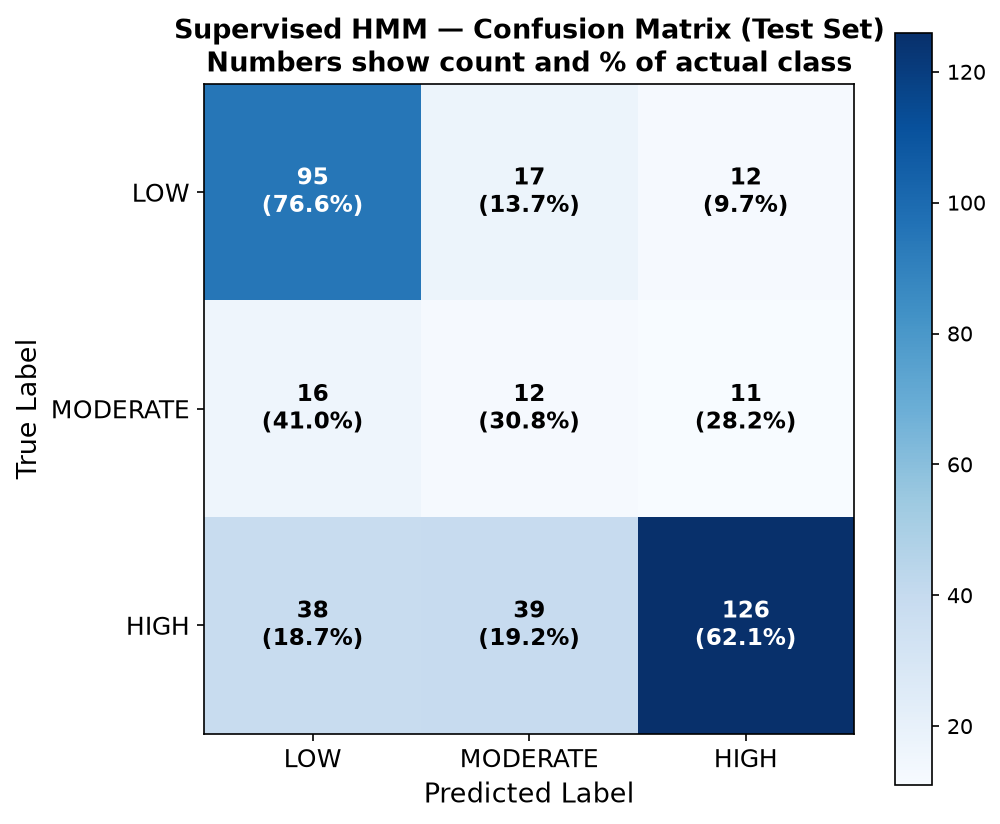


Supervised HMM Classification Report:
              precision    recall  f1-score   support

         LOW       0.64      0.77      0.70       124
    MODERATE       0.18      0.31      0.22        39
        HIGH       0.85      0.62      0.72       203

    accuracy                           0.64       366
   macro avg       0.55      0.56      0.55       366
weighted avg       0.70      0.64      0.66       366



In [3]:
N_HIDDEN = 2
class_models_sup = {}

for class_idx in range(3):
    class_name = le.classes_[class_idx]
    class_seqs = X_train_scaled[y_train == class_idx]
    if len(class_seqs) < 5:
        print(f"Skipping {class_name}: only {len(class_seqs)} sequences")
        continue
    lengths = [6] * len(class_seqs)
    X_concat = class_seqs.reshape(-1, 4)
    model = hmm.GaussianHMM(n_components=N_HIDDEN, covariance_type='diag',
                             n_iter=100, random_state=42)
    model.fit(X_concat, lengths)
    class_models_sup[class_idx] = model
    print(f"Trained supervised HMM for {class_name}: {len(class_seqs)} sequences")

def predict_supervised(seq_scaled, models):
    scores = {ci: m.score(seq_scaled) for ci, m in models.items()}
    return max(scores, key=scores.get)

y_train_pred_sup = np.array([predict_supervised(X_train_scaled[i], class_models_sup)
                              for i in range(len(X_train_scaled))])
y_test_pred_sup = np.array([predict_supervised(X_test_scaled[i], class_models_sup)
                             for i in range(len(X_test_scaled))])

def compute_metrics(y_true, y_pred, label):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    rec = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    print(f"\n{label}: Acc={acc:.4f} Prec={prec:.4f} Rec={rec:.4f} F1={f1:.4f}")
    return {'accuracy': acc, 'precision': prec, 'recall': rec, 'f1': f1}

print("=" * 50)
print("SECTION A — SUPERVISED HMM RESULTS")
print("=" * 50)
hmm_sup_train = compute_metrics(y_train, y_train_pred_sup, "Supervised HMM - TRAIN")
hmm_sup_test = compute_metrics(y_test, y_test_pred_sup, "Supervised HMM - TEST")
overfit_gap_sup = hmm_sup_train['accuracy'] - hmm_sup_test['accuracy']
print(f"\nOverfit gap: {overfit_gap_sup:.4f}")

# Convert per-class HMM likelihood scores into pseudo-probabilities
# via softmax, to enable AUC-ROC computation (HMMs don't natively
# output calibrated probabilities the way XGBoost/LSTM do).
from scipy.special import softmax

def get_supervised_proba(seq_scaled, models, n_classes=3):
    scores = np.full(n_classes, -np.inf)
    for ci, m in models.items():
        try:
            scores[ci] = m.score(seq_scaled)
        except:
            pass
    return softmax(scores)

test_proba_hmm_sup = np.array([
    get_supervised_proba(X_test_scaled[i], class_models_sup)
    for i in range(len(X_test_scaled))
])

y_test_bin = label_binarize(y_test, classes=[0, 1, 2])
hmm_sup_auc = roc_auc_score(y_test_bin, test_proba_hmm_sup,
                              average='weighted', multi_class='ovr')
print(f"Supervised HMM AUC-ROC: {hmm_sup_auc:.4f}")

# Confusion matrix
cm_sup = confusion_matrix(y_test, y_test_pred_sup)
print("\nSupervised HMM Confusion Matrix (test set):")
print(pd.DataFrame(cm_sup, index=le.classes_, columns=le.classes_))

# Visual confusion matrix for supervised HMM
fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(cm_sup, cmap='Blues')

plt.colorbar(im, ax=ax)

class_labels = le.classes_
ax.set_xticks(range(len(class_labels)))
ax.set_yticks(range(len(class_labels)))
ax.set_xticklabels(class_labels, fontsize=12)
ax.set_yticklabels(class_labels, fontsize=12)

for i in range(len(class_labels)):
    for j in range(len(class_labels)):
        count = cm_sup[i, j]
        total_actual = cm_sup[i, :].sum()
        pct = count / total_actual * 100
        text_color = 'white' if count > cm_sup.max() / 2 else 'black'
        ax.text(j, i, f'{count}\n({pct:.1f}%)',
                ha='center', va='center',
                color=text_color, fontsize=11, fontweight='bold')

ax.set_xlabel('Predicted Label', fontsize=13)
ax.set_ylabel('True Label', fontsize=13)
ax.set_title('Supervised HMM — Confusion Matrix (Test Set)\n'
             'Numbers show count and % of actual class',
             fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig(FIGURES_DIR / '22a_hmm_supervised_confusion_matrix.png',
            dpi=150, bbox_inches='tight')
plt.close()
print("Saved: outputs/figures/22a_hmm_supervised_confusion_matrix.png")

from IPython.display import Image as IPImage, display
display(IPImage(str(FIGURES_DIR / '22a_hmm_supervised_confusion_matrix.png')))

# Full classification report for completeness
from sklearn.metrics import classification_report
print("\nSupervised HMM Classification Report:")
print(classification_report(y_test, y_test_pred_sup,
                            target_names=le.classes_, zero_division=0))

In [4]:
# Empirical transition matrix: how often does meal slot i's risk
# behavior transition to slot i+1's, based on per-meal nutrient
# exceedance counted the same way daily risk labels were derived.

THRESHOLDS = {
    'G2': {'potassium': 3500/3, 'phosphorus': 1000/3, 'protein': 0.8/3, 'sodium': 2300/3},
}
t = THRESHOLDS['G2']  # per-meal approx (daily limit / 3 meals)

def meal_risk_state(meal_vec):
    k, p, pr, s = meal_vec
    exceed_count = sum([k > t['potassium'], p > t['phosphorus'],
                        pr > t['protein'], s > t['sodium']])
    if exceed_count >= 2:
        return 2  # HIGH
    elif exceed_count == 1:
        return 1  # MODERATE
    return 0  # LOW

transition_counts = np.zeros((3, 3))
for seq in X_train:
    states = [meal_risk_state(seq[i]) for i in range(6)]
    for i in range(5):
        transition_counts[states[i], states[i+1]] += 1

transition_matrix = transition_counts / transition_counts.sum(axis=1, keepdims=True)
transition_matrix = np.nan_to_num(transition_matrix)

print("Transition matrix (rows=from, cols=to):")
print(pd.DataFrame(transition_matrix, index=['LOW','MODERATE','HIGH'],
                   columns=['LOW','MODERATE','HIGH']))

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(transition_matrix, annot=True, fmt='.3f', cmap='Blues',
           xticklabels=['LOW','MODERATE','HIGH'],
           yticklabels=['LOW','MODERATE','HIGH'], ax=ax)
ax.set_xlabel('To State')
ax.set_ylabel('From State')
ax.set_title('Meal-to-Meal Risk State Transition Matrix')
plt.tight_layout()
plt.savefig(FIGURES_DIR / '19_hmm_transition_matrix.png', dpi=150, bbox_inches='tight')
plt.close()
print("Saved: outputs/figures/19_hmm_transition_matrix.png")

Transition matrix (rows=from, cols=to):
               LOW  MODERATE      HIGH
LOW       0.492208  0.095560  0.412232
MODERATE  0.291925  0.130435  0.577640
HIGH      0.369942  0.111111  0.518947


Saved: outputs/figures/19_hmm_transition_matrix.png


## Section B — Extended HMM (Unsupervised Baum-Welch)

A single 3-state Gaussian HMM is trained using Baum-Welch (EM) on all training sequences WITHOUT using the labels, allowing the model to discover states from the data itself. Discovered states are then mapped to LOW/MODERATE/HIGH by matching each discovered state's mean nutrient profile to the closest labeled class.

In [5]:
X_train_concat = X_train_scaled.reshape(-1, 4)
lengths_train = [6] * len(X_train_scaled)

unsup_model = hmm.GaussianHMM(n_components=6, covariance_type='diag',
                               n_iter=200, random_state=42,
                               min_covar=0.01)
unsup_model.fit(X_train_concat, lengths_train)

# Verify Baum-Welch convergence by examining the log-likelihood
# history across EM iterations. If the curve flattens out before
# n_iter is reached, the algorithm converged properly. If it's
# still climbing at the final iteration, more iterations may be
# needed.
log_likelihood_history = unsup_model.monitor_.history

print(f"Number of EM iterations run: {len(log_likelihood_history)}")
print(f"Did the model converge? {unsup_model.monitor_.converged}")
print(f"Final log-likelihood: {log_likelihood_history[-1]:.2f}")

if len(log_likelihood_history) > 1:
    improvement_last_step = log_likelihood_history[-1] - log_likelihood_history[-2]
    print(f"Log-likelihood improvement on final iteration: {improvement_last_step:.4f}")
    if abs(improvement_last_step) < 0.01:
        print("Improvement is negligible - model has effectively converged.")
    else:
        print("Improvement is still non-trivial - consider increasing n_iter.")

# Plot the convergence curve
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(range(1, len(log_likelihood_history) + 1), log_likelihood_history,
        marker='o', markersize=3, color='#2E86AB', linewidth=1.5)
ax.set_xlabel('EM Iteration')
ax.set_ylabel('Log-Likelihood')
ax.set_title('Baum-Welch Convergence — Unsupervised HMM Training')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_DIR / '21_hmm_baum_welch_convergence.png', dpi=150, bbox_inches='tight')
plt.close()
print("Saved: outputs/figures/21_hmm_baum_welch_convergence.png")

# Decode training sequences to discover which hidden state index
# corresponds to which risk label
decoded_train_states = []
for seq in X_train_scaled:
    _, state_seq = unsup_model.decode(seq, algorithm='viterbi')
    decoded_train_states.append(state_seq[-1])  # final state of sequence
decoded_train_states = np.array(decoded_train_states)

state_to_label = {}
overall_high_rate = (y_train == 2).mean()
overall_moderate_rate = (y_train == 1).mean()

for state_idx in range(6):
    mask = decoded_train_states == state_idx
    if mask.sum() == 0:
        state_to_label[state_idx] = 0
        continue

    low_rate = (y_train[mask] == 0).mean()
    moderate_rate = (y_train[mask] == 1).mean()
    high_rate = (y_train[mask] == 2).mean()
    rates = {0: low_rate, 1: moderate_rate, 2: high_rate}

    majority_label = max(rates, key=rates.get)
    majority_rate = rates[majority_label]

    # Only override the majority with enrichment logic if the
    # majority itself is weak (no class clearly dominates, e.g.
    # all three are within a similar range) - otherwise trust
    # the majority.
    if majority_rate < 0.45:  # no clear majority
        if high_rate > overall_high_rate * 1.3 and high_rate > 0.20:
            state_to_label[state_idx] = 2
        elif moderate_rate > overall_moderate_rate * 1.3 and moderate_rate > 0.12:
            state_to_label[state_idx] = 1
        else:
            state_to_label[state_idx] = majority_label
    else:
        state_to_label[state_idx] = majority_label

print("Corrected state -> label mapping:", state_to_label)
for state_idx in range(6):
    mask = decoded_train_states == state_idx
    if mask.sum() > 0:
        print(f"  State {state_idx} (n={mask.sum()}): "
              f"LOW={(y_train[mask]==0).mean():.2f} "
              f"MODERATE={(y_train[mask]==1).mean():.2f} "
              f"HIGH={(y_train[mask]==2).mean():.2f} "
              f"-> {le.classes_[state_to_label[state_idx]]}")

def predict_unsupervised(seq_scaled, model, mapping):
    _, state_seq = model.decode(seq_scaled, algorithm='viterbi')
    final_state = state_seq[-1]
    return mapping.get(final_state, 0), state_seq

y_test_pred_unsup = []
decoded_sequences_test = []
for seq in X_test_scaled:
    pred, full_path = predict_unsupervised(seq, unsup_model, state_to_label)
    y_test_pred_unsup.append(pred)
    decoded_sequences_test.append(full_path)
y_test_pred_unsup = np.array(y_test_pred_unsup)

y_train_pred_unsup = []
for seq in X_train_scaled:
    pred, _ = predict_unsupervised(seq, unsup_model, state_to_label)
    y_train_pred_unsup.append(pred)
y_train_pred_unsup = np.array(y_train_pred_unsup)

print("=" * 50)
print("SECTION B — UNSUPERVISED HMM RESULTS")
print("=" * 50)
hmm_unsup_train = compute_metrics(y_train, y_train_pred_unsup, "Unsupervised HMM - TRAIN")
hmm_unsup_test = compute_metrics(y_test, y_test_pred_unsup, "Unsupervised HMM - TEST")
overfit_gap_unsup = hmm_unsup_train['accuracy'] - hmm_unsup_test['accuracy']
print(f"\nOverfit gap: {overfit_gap_unsup:.4f}")

# For the unsupervised HMM, convert the per-timestep state
# posterior probabilities (predict_proba from hmmlearn) into a
# sequence-level class probability by mapping each hidden state's
# posterior mass to its assigned label, using the FINAL timestep's
# posterior (matching how predictions are made elsewhere in this
# notebook - final state determines the prediction).

def get_unsupervised_proba(seq_scaled, model, mapping, n_classes=3):
    posteriors = model.predict_proba(seq_scaled)  # shape (6, n_components)
    final_posterior = posteriors[-1]  # last timestep
    class_proba = np.zeros(n_classes)
    for state_idx, label_idx in mapping.items():
        class_proba[label_idx] += final_posterior[state_idx]
    total = class_proba.sum()
    if total > 0:
        class_proba = class_proba / total
    return class_proba

test_proba_hmm_unsup = np.array([
    get_unsupervised_proba(X_test_scaled[i], unsup_model, state_to_label)
    for i in range(len(X_test_scaled))
])

hmm_unsup_auc = roc_auc_score(y_test_bin, test_proba_hmm_unsup,
                                average='weighted', multi_class='ovr')
print(f"Unsupervised HMM AUC-ROC: {hmm_unsup_auc:.4f}")

# Confusion matrix
cm_unsup = confusion_matrix(y_test, y_test_pred_unsup)
print("\nUnsupervised HMM Confusion Matrix (test set):")
print(pd.DataFrame(cm_unsup, index=le.classes_, columns=le.classes_))

print("\nUnsupervised HMM Classification Report:")
print(classification_report(y_test, y_test_pred_unsup,
                            target_names=le.classes_, zero_division=0))

Number of EM iterations run: 185
Did the model converge? True
Final log-likelihood: 11493.15
Log-likelihood improvement on final iteration: 0.0096
Improvement is negligible - model has effectively converged.
Saved: outputs/figures/21_hmm_baum_welch_convergence.png
Corrected state -> label mapping: {0: 2, 1: 0, 2: 2, 3: 1, 4: 0, 5: 2}
  State 0 (n=354): LOW=0.26 MODERATE=0.16 HIGH=0.58 -> HIGH
  State 1 (n=336): LOW=0.90 MODERATE=0.04 HIGH=0.07 -> LOW
  State 2 (n=472): LOW=0.08 MODERATE=0.13 HIGH=0.79 -> HIGH
  State 3 (n=36): LOW=0.39 MODERATE=0.19 HIGH=0.42 -> MODERATE
  State 4 (n=111): LOW=0.44 MODERATE=0.14 HIGH=0.42 -> LOW
  State 5 (n=155): LOW=0.02 MODERATE=0.04 HIGH=0.94 -> HIGH
SECTION B — UNSUPERVISED HMM RESULTS



Unsupervised HMM - TRAIN: Acc=0.7404 Prec=0.6963 Rec=0.7404 F1=0.7085

Unsupervised HMM - TEST: Acc=0.7678 Prec=0.7337 Rec=0.7678 F1=0.7421

Overfit gap: -0.0273
Unsupervised HMM AUC-ROC: 0.8430

Unsupervised HMM Confusion Matrix (test set):
          LOW  MODERATE  HIGH
LOW        93         7    24
MODERATE   11         4    24
HIGH       18         1   184

Unsupervised HMM Classification Report:
              precision    recall  f1-score   support

         LOW       0.76      0.75      0.76       124
    MODERATE       0.33      0.10      0.16        39
        HIGH       0.79      0.91      0.85       203

    accuracy                           0.77       366
   macro avg       0.63      0.59      0.59       366
weighted avg       0.73      0.77      0.74       366



Saved: outputs/figures/22_hmm_confusion_matrices.png (updated)


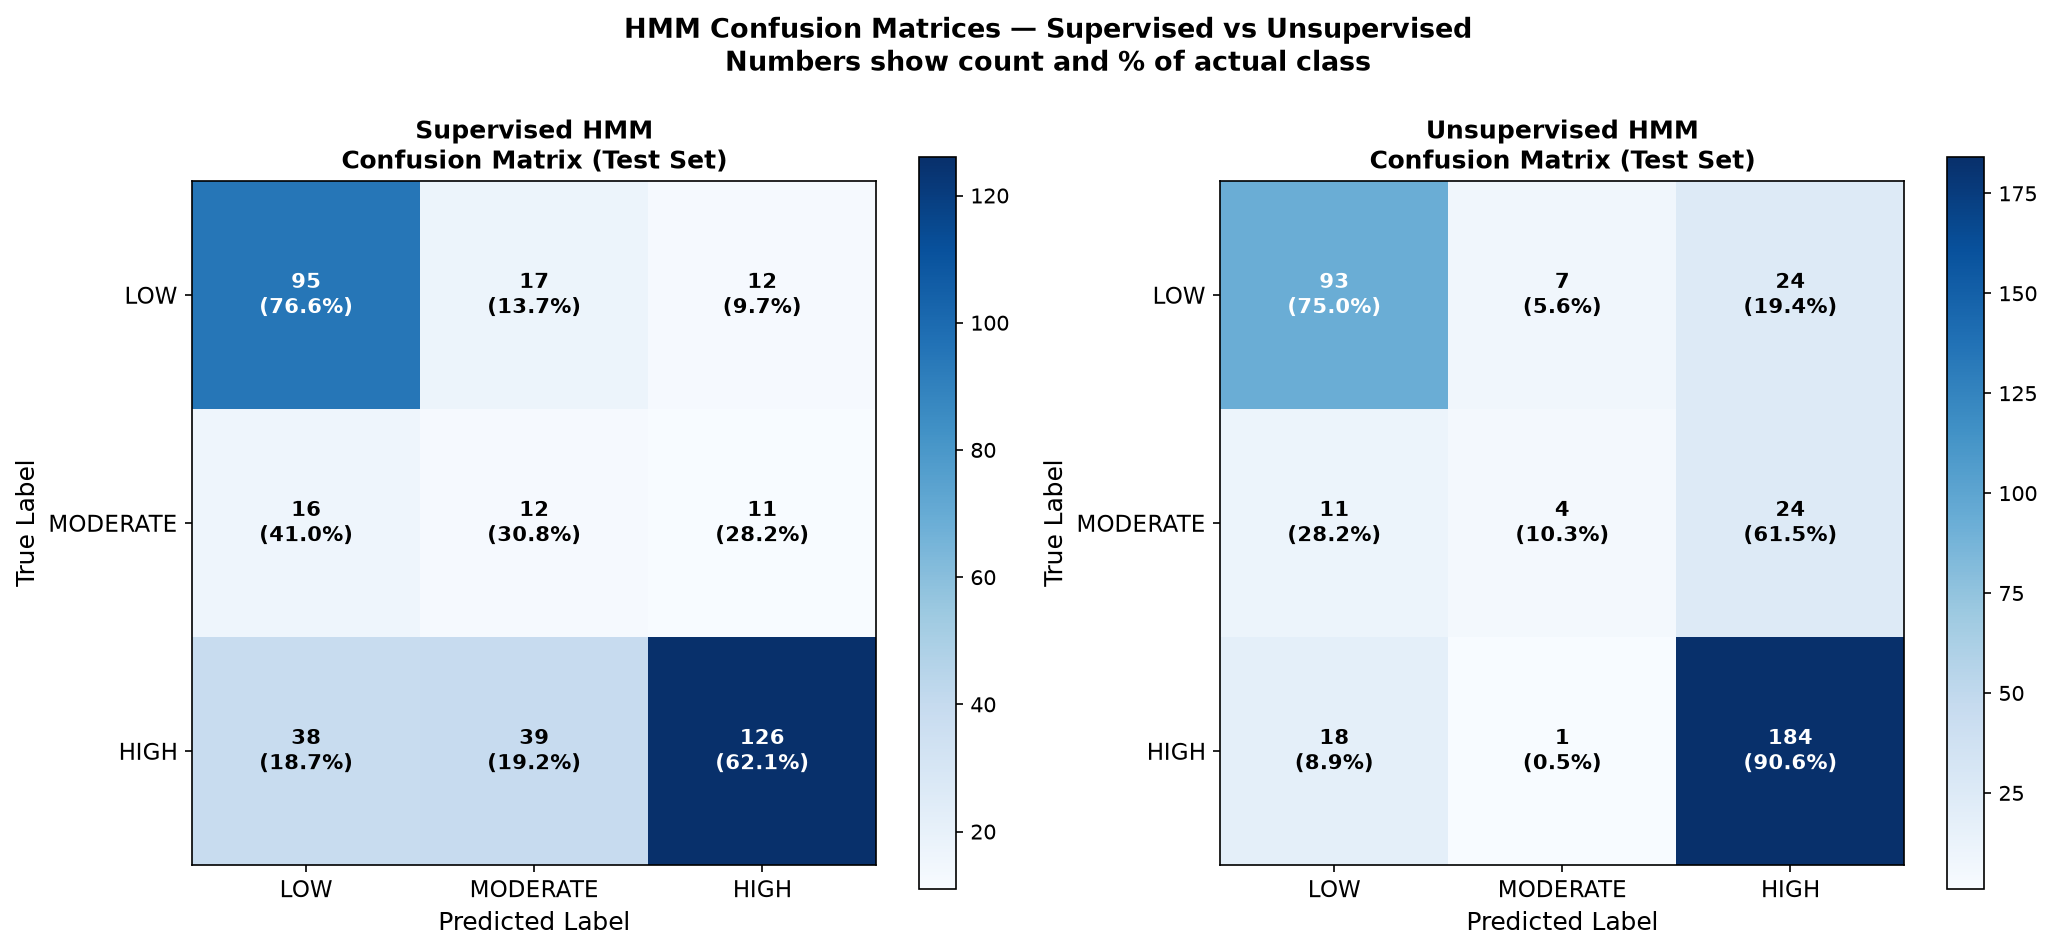

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, (name, cm) in zip(axes, [
    ('Supervised HMM', cm_sup),
    ('Unsupervised HMM', cm_unsup)
]):
    im = ax.imshow(cm, cmap='Blues')
    plt.colorbar(im, ax=ax)
    
    ax.set_xticks(range(len(class_labels)))
    ax.set_yticks(range(len(class_labels)))
    ax.set_xticklabels(class_labels, fontsize=11)
    ax.set_yticklabels(class_labels, fontsize=11)
    ax.set_xlabel('Predicted Label', fontsize=12)
    ax.set_ylabel('True Label', fontsize=12)
    ax.set_title(f'{name}\nConfusion Matrix (Test Set)', 
                 fontsize=12, fontweight='bold')
    
    for i in range(len(class_labels)):
        for j in range(len(class_labels)):
            count = cm[i, j]
            total_actual = cm[i, :].sum()
            pct = count / total_actual * 100
            text_color = 'white' if count > cm.max() / 2 else 'black'
            ax.text(j, i, f'{count}\n({pct:.1f}%)',
                    ha='center', va='center',
                    color=text_color, fontsize=10, fontweight='bold')

plt.suptitle('HMM Confusion Matrices — Supervised vs Unsupervised\n'
             'Numbers show count and % of actual class',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_DIR / '22_hmm_confusion_matrices.png',
            dpi=150, bbox_inches='tight')
plt.close()
print("Saved: outputs/figures/22_hmm_confusion_matrices.png (updated)")

display(IPImage(str(FIGURES_DIR / '22_hmm_confusion_matrices.png')))

In [7]:
fig, axes = plt.subplots(3, 1, figsize=(10, 8))
label_names = ['LOW', 'MODERATE', 'HIGH']

for idx, ax in enumerate(axes):
    if idx >= len(decoded_sequences_test):
        break
    path = decoded_sequences_test[idx]
    mapped_path = [state_to_label.get(s, 0) for s in path]
    ax.plot(range(1, 7), mapped_path, marker='o', linewidth=2, color='#2E86AB')
    ax.set_yticks([0, 1, 2])
    ax.set_yticklabels(label_names)
    ax.set_xlabel('Meal occasion (1-6, Day1 B/L/D, Day2 B/L/D)')
    ax.set_title(f'Test Patient {idx+1} - Decoded Risk State Path')
    ax.set_ylim(-0.5, 2.5)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / '20_hmm_decoded_sequences.png', dpi=150, bbox_inches='tight')
plt.close()
print("Saved: outputs/figures/20_hmm_decoded_sequences.png")

Saved: outputs/figures/20_hmm_decoded_sequences.png


In [8]:
# Per-state sensitivity/specificity/accuracy table - matches reference format:
def per_state_metrics(y_true, y_pred, state_names):
    results = []
    for i, name in enumerate(state_names):
        tp = np.sum((y_true == i) & (y_pred == i))
        fn = np.sum((y_true == i) & (y_pred != i))
        tn = np.sum((y_true != i) & (y_pred != i))
        fp = np.sum((y_true != i) & (y_pred == i))
        sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
        specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
        accuracy = (tp + tn) / (tp + tn + fp + fn)
        n_samples = np.sum(y_true == i)
        results.append({
            'State': name, 'Number of Samples': n_samples,
            'Sensitivity': round(sensitivity, 4),
            'Specificity': round(specificity, 4),
            'Overall Accuracy': round(accuracy, 4)
        })
    return pd.DataFrame(results)

print("Supervised HMM - per-state metrics (test set):")
table_sup = per_state_metrics(y_test, y_test_pred_sup, ['LOW', 'MODERATE', 'HIGH'])
print(table_sup.to_string(index=False))

print("\nUnsupervised HMM - per-state metrics (test set):")
table_unsup = per_state_metrics(y_test, y_test_pred_unsup, ['LOW', 'MODERATE', 'HIGH'])
print(table_unsup.to_string(index=False))

table_sup.to_csv(STATS_DIR / '12_hmm_supervised_per_state.csv', index=False)
table_unsup.to_csv(STATS_DIR / '13_hmm_unsupervised_per_state.csv', index=False)
print("\nSaved both per-state tables to outputs/stats/")

Supervised HMM - per-state metrics (test set):
   State  Number of Samples  Sensitivity  Specificity  Overall Accuracy
     LOW                124       0.7661       0.7769            0.7732
MODERATE                 39       0.3077       0.8287            0.7732
    HIGH                203       0.6207       0.8589            0.7268

Unsupervised HMM - per-state metrics (test set):
   State  Number of Samples  Sensitivity  Specificity  Overall Accuracy
     LOW                124       0.7500       0.8802            0.8361
MODERATE                 39       0.1026       0.9755            0.8825
    HIGH                203       0.9064       0.7055            0.8169

Saved both per-state tables to outputs/stats/


In [9]:
from tensorflow.keras.models import load_model

lstm_model = load_model(MODEL_DIR / 'lstm_final.keras')
lstm_scaler = joblib.load(MODEL_DIR / 'lstm_scaler.pkl')

def predict_lstm_batch(X, scaler, model):
    """
    X shape: (n_patients, 6, 4)
    Scaler expects (n_samples, 4) - scale each timestep independently,
    then reshape back to (n_patients, 6, 4) for the LSTM.
    """
    n_patients, n_steps, n_features = X.shape

    # Flatten to (n_patients * 6, 4) so each meal-step is one row
    X_reshaped = X.reshape(-1, n_features)

    # Scale - scaler expects 4 columns, this now matches
    X_scaled = scaler.transform(X_reshaped)

    # Reshape back to (n_patients, 6, 4) for LSTM input
    X_scaled = X_scaled.reshape(n_patients, n_steps, n_features)

    proba = model.predict(X_scaled, verbose=0)
    return np.argmax(proba, axis=1), proba

print(f"X_train range before LSTM scaling: min={X_train.min():.2f}, max={X_train.max():.2f}")

y_train_pred_lstm, _ = predict_lstm_batch(X_train, lstm_scaler, lstm_model)
y_test_pred_lstm, test_proba_lstm = predict_lstm_batch(X_test, lstm_scaler, lstm_model)

lstm_train = compute_metrics(y_train, y_train_pred_lstm, "LSTM - TRAIN")
lstm_test = compute_metrics(y_test, y_test_pred_lstm, "LSTM - TEST")
overfit_gap_lstm = lstm_train['accuracy'] - lstm_test['accuracy']
print(f"\nLSTM overfit gap: {overfit_gap_lstm:.4f}")

y_test_bin = label_binarize(y_test, classes=[0, 1, 2])
lstm_auc = roc_auc_score(y_test_bin, test_proba_lstm, average='weighted', multi_class='ovr')
print(f"LSTM AUC-ROC: {lstm_auc:.4f}")

X_train range before LSTM scaling: min=0.00, max=1730.00

LSTM - TRAIN: Acc=0.9064 Prec=0.9035 Rec=0.9064 F1=0.9048

LSTM - TEST: Acc=0.9071 Prec=0.9048 Rec=0.9071 F1=0.9052

LSTM overfit gap: -0.0007
LSTM AUC-ROC: 0.9825



In [10]:
comparison = pd.DataFrame({
    'Model': ['HMM (Supervised)', 'HMM (Unsupervised)', 'LSTM'],
    'Train Accuracy': [hmm_sup_train['accuracy'], hmm_unsup_train['accuracy'], lstm_train['accuracy']],
    'Test Accuracy': [hmm_sup_test['accuracy'], hmm_unsup_test['accuracy'], lstm_test['accuracy']],
    'Overfit Gap': [overfit_gap_sup, overfit_gap_unsup, overfit_gap_lstm],
    'Test Precision': [hmm_sup_test['precision'], hmm_unsup_test['precision'], lstm_test['precision']],
    'Test Recall': [hmm_sup_test['recall'], hmm_unsup_test['recall'], lstm_test['recall']],
    'Test F1': [hmm_sup_test['f1'], hmm_unsup_test['f1'], lstm_test['f1']],
    'Test AUC-ROC': [hmm_sup_auc, hmm_unsup_auc, lstm_auc],
})

print("=" * 70)
print("MASTER COMPARISON — SUPERVISED HMM vs UNSUPERVISED HMM vs LSTM")
print("=" * 70)
print(comparison.to_string(index=False))

best_idx = comparison['Test Accuracy'].idxmax()
print(f"\nBest performing model: {comparison.loc[best_idx, 'Model']} "
      f"({comparison.loc[best_idx, 'Test Accuracy']:.4f} test accuracy)")

comparison.to_csv(STATS_DIR / '14_master_three_way_comparison.csv', index=False)
print("\nSaved: outputs/stats/14_master_three_way_comparison.csv")

MASTER COMPARISON — SUPERVISED HMM vs UNSUPERVISED HMM vs LSTM
             Model  Train Accuracy  Test Accuracy  Overfit Gap  Test Precision  Test Recall  Test F1  Test AUC-ROC
  HMM (Supervised)        0.637978       0.636612     0.001366        0.703845     0.636612 0.656769      0.848033
HMM (Unsupervised)        0.740437       0.767760    -0.027322        0.733674     0.767760 0.742096      0.842955
              LSTM        0.906421       0.907104    -0.000683        0.904800     0.907104 0.905178      0.982506

Best performing model: LSTM (0.9071 test accuracy)

Saved: outputs/stats/14_master_three_way_comparison.csv

